# **Data Loading**

In [1]:
# Import the required libraries
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv('titanic_train.csv')

# Display the dataset
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# **Data Exploration**

In [10]:
# Basic information about the dataset
print("\nBasic Information:")
print(df.info())


Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [9]:
# Summary Statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [8]:
# Total rows and columns
print("\nTotal rows and columns:")
print(df.shape)


Total rows and columns:
(891, 12)


In [5]:
# Columns with missing values
print("\nColumns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Columns with missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [6]:
# Numerical columns list
print("\nNumerical columns:")
print(df.select_dtypes(include="number").columns.tolist())


Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [7]:
# Categorical columns list
print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())


Categorical columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## **Data Story - First Look at the Titanic Training Dataset**

- The dataset has **891 rows and 12 columns**, each row representing one passenger.
- **Three columns have missing values:** Cabin (687 missing — ~77% of the column), Age (177 missing), and Embarked (2 missing).
- **Numerical columns:** PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare.
- **Categorical columns:** Name, Sex, Ticket, Cabin, and Embarked.
- `Survived` is the target (0 = did not survive, 1 = survived); overall survival was about 38%.
- `Pclass` is numeric in storage but really a category (1st/2nd/3rd class).
- Biggest data-quality concern: Cabin is mostly empty, so it will likely be dropped.

# **Handling Missing Values**

In [12]:
# Age: fill with median (robust to skew and outliers)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: only 2 missing — fill with mode (most common port)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: ~77% missing — too sparse to impute, so drop it
df = df.drop(columns=["Cabin"])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### **Missing Value Handling — Justification**
- **Age (177 missing):** filled with the *median*, which is robust to skew so extreme ages don't distort the fill.
- **Embarked (2 missing):** only two values missing, so filled with the *mode* (most common port) — minimal impact.
- **Cabin (687 missing, ~77%):** far too sparse to impute reliably, so the column was *dropped* rather than inventing data for most passengers.

# **Outlier Detection With Box Plot**

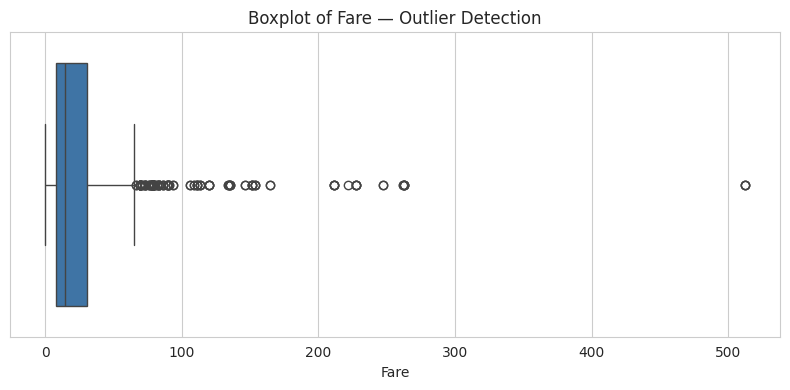

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Box plot for Fare column
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Fare"], color="#2E75B6")
plt.title("Boxplot of Fare — Outlier Detection")
plt.tight_layout()
plt.show()

# **Historgram**

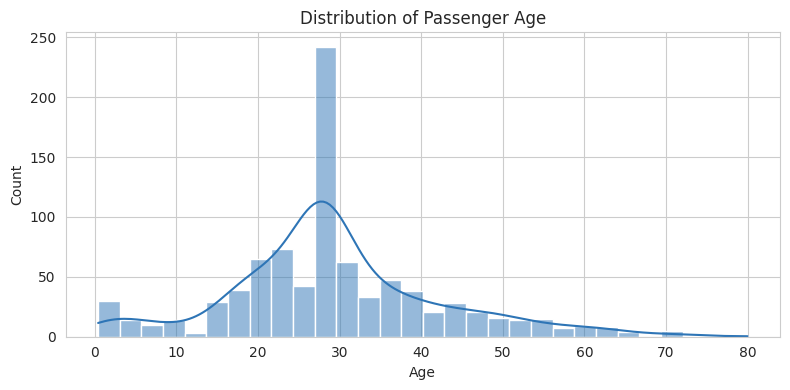

In [15]:
# Histogram for Age column
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=30, kde=True, color="#2E75B6")
plt.title("Distribution of Passenger Age")
plt.tight_layout()
plt.show()

# **Box Plot**

/tmp/ipykernel_830/2101982808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="Blues")


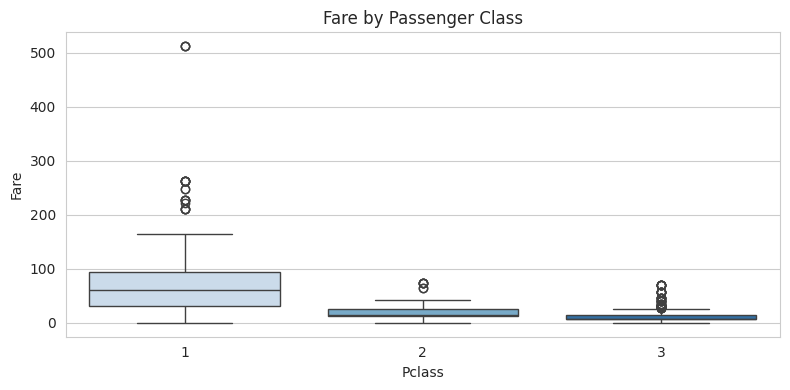

In [17]:
# Box plot for Fare by Class
plt.figure(figsize=(8,4))
sns.boxplot(x="Pclass", y="Fare", data=df, palette="Blues")
plt.title("Fare by Passenger Class")
plt.tight_layout()
plt.show()

# **Bar Chart**

/tmp/ipykernel_830/1149134295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="Blues")


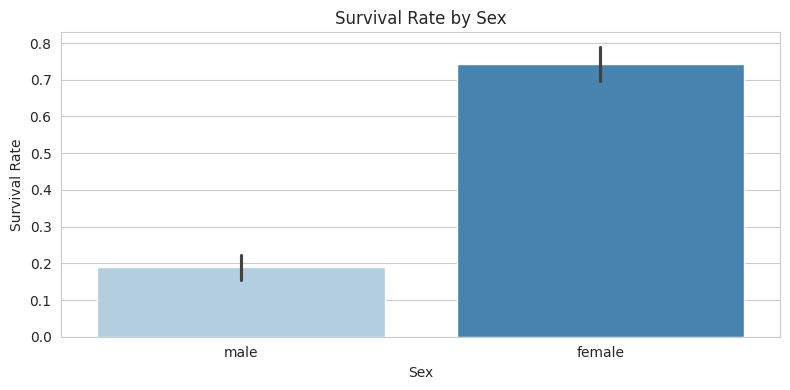

In [18]:
# Bar chart for Survival Rate by Sex
plt.figure(figsize=(8,4))
sns.barplot(x="Sex", y="Survived", data=df, palette="Blues")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

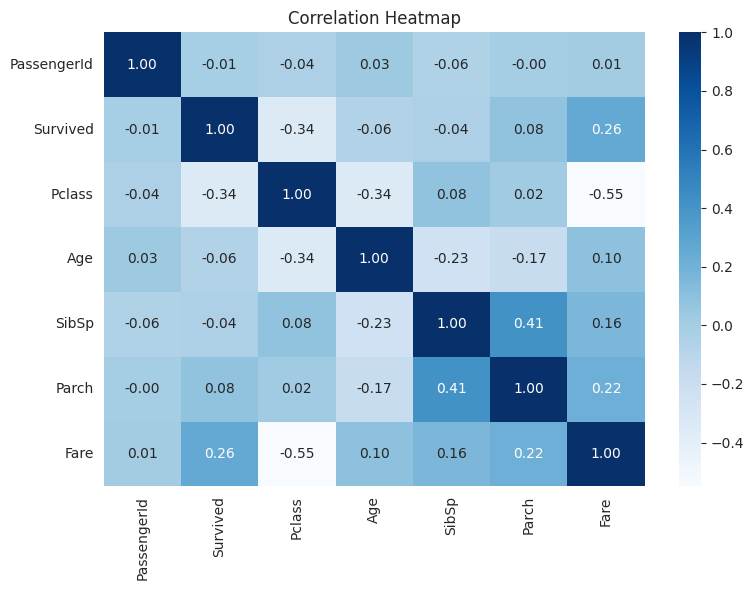

In [20]:
# Correlation heatmap for numerical columns only
plt.figure(figsize=(8,6))
numeric = df.select_dtypes(include="number")
sns.heatmap(numeric.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### **Which feature most affects survival, and why?**

**Sex is the feature that most affects survival.** In this dataset, **74.2% of women survived versus only 18.9% of men** — a dramatic gap reflecting the "women and children first" evacuation.

Passenger class is the second strongest factor: **1st class survived at 63%, 2nd at 47%, 3rd at just 24%**, and Pclass has the strongest *numeric* correlation with survival (-0.34, negative because a lower class number means higher status). Fare shows a similar but weaker effect (+0.26), mostly because higher fares track with higher class.

So survival was driven mainly by **who you were (sex) and how wealthy you were (class/fare)** — not by age, which showed almost no correlation (-0.08).